# 06 — InternVL3-2B Zero-shot: Inference Health and Hold-out Results

`OpenGVLab/InternVL3-2B` zero-shot inference, top-3 SVI per building, 6-field JSON-constrained prompt. Per-image predictions are aggregated per `pand_id` via majority vote (`building_type`, `construction_period`, `facade_material`) and median (`construction_year`, `num_floors`).

Output schema is locked to match Notebook 05 (`T2_dinov2_holdout_headline`) so the two headline tables can be `pd.concat`-ed without column renaming.

### Verbatim prompt (from `src/stage1/vlm/internvl3_runner.py`)

```
Look at this Dutch building street-view photo. Identify its physical characteristics for a building-energy classification task.

Respond with EXACTLY one JSON object, no markdown fences, no extra text. You MUST provide values for ALL fields. NEVER return null.

Required keys:

- "building_type": one of:
    "SFH" = Single Family House: detached or semi-detached, standalone with garden
    "TH"  = Terraced House: shares side walls with neighbors in a row
    "AB"  = Apartment Block: building containing multiple SELF-CONTAINED apartments
            with shared main entrance, often long linear or block-shaped facade.
            DEFAULT for any multi-unit residential building.
    "MFH" = Multi Family House: rare collective housing where units share NO
            self-contained dwellings (rooming houses, student dormitories,
            elderly care).

- "construction_year": integer 1800-2025. Estimate from facade style, materials,
  window patterns. Do NOT default to period boundary years (1964, 1975, 1991,
  1992, 2005, 2014).

- "construction_period": one of (must match construction_year):
    "NL.01" = up to 1964      "NL.02" = 1965-1974
    "NL.03" = 1975-1991       "NL.04" = 1992-2005
    "NL.05" = 2006-2014       "NL.06" = 2015 and later

- "num_floors": integer 1-30 (visible storeys above ground)

- "facade_material": one of "brick", "concrete", "wood", "stucco", "metal",
  "stone", "mixed", "other"

Example:
{"building_type": "AB", "construction_year": 1968, "construction_period": "NL.02", "num_floors": 4, "facade_material": "brick"}
```

In [1]:
import sys, json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd()))
from _stage1_plot import (
    REPO, FIG_DIR, TABLE_DIR, REPORTS_DIR,
    setup_mpl, save_fig, save_table, confusion_heatmap,
    compute_locked_limits, provenance_table,
    TYPE_LABELS, CITY_LABELS, TYPE_PALETTE, CITY_PALETTE,
)

setup_mpl()
AXIS_LIMITS = compute_locked_limits()

VLM_DIR = REPORTS_DIR / 'vlm'
per_image_path   = VLM_DIR / 'internvl3_holdout_per_image.parquet'
per_pand_path    = VLM_DIR / 'internvl3_holdout_per_pand_id.parquet'
ho_metrics_path  = VLM_DIR / 'internvl3_holdout_metrics.json'

per_image = pd.read_parquet(per_image_path)
per_pand  = pd.read_parquet(per_pand_path)
ho_metrics = json.loads(ho_metrics_path.read_text())

prov_df = provenance_table([per_image_path, per_pand_path, ho_metrics_path])
print('AXIS_LIMITS (shared with Notebook 05):', AXIS_LIMITS)
print(f'per_image n={len(per_image):,}  per_pand_id n={len(per_pand):,}')
prov_df

AXIS_LIMITS (shared with Notebook 05): {'year_scatter': (1850, 2030), 'year_mae_bar': (0.0, 64), 'floors_mae_bar': (0.0, 0.9), 'type_acc_bar': (0.0, 1.0)}
per_image n=5,261  per_pand_id n=2,018


,file,size_kb,mtime
0,reports\stage1\vlm\internvl3_holdout_per_image...,322.9,2026-05-23 05:52
1,reports\stage1\vlm\internvl3_holdout_per_pand_...,40.4,2026-05-23 05:53
2,reports\stage1\vlm\internvl3_holdout_metrics.json,2.8,2026-05-23 05:55


## 1. Inference health

In [2]:
n_image          = len(per_image)
parse_ok_pct     = per_image['parse_ok'].mean() * 100
inf_sec_median   = per_image['inference_sec'].median()
yp_consistent_pct = per_image.loc[per_image['parse_ok'], 'year_period_consistent'].mean() * 100

health = pd.DataFrame([{
    'n_image':                n_image,
    'n_pand_id':              len(per_pand),
    'parse_ok_pct':           round(parse_ok_pct, 2),
    'inference_sec_median':   round(inf_sec_median, 3),
    'year_period_consistent_pct': round(yp_consistent_pct, 2),
}])
save_table(health, 'T1_vlm_inference_health')
health.T

[tbl] reports\tables\stage1\T1_vlm_inference_health.csv  +  T1_vlm_inference_health.md


,0
n_image,5261.00
n_pand_id,2018.00
parse_ok_pct,99.05
inference_sec_median,3.83
year_period_consistent_pct,91.54


## 2. Hold-out test results

In [3]:
n_dropped = int(per_pand['pred_type'].isna().sum())
print(f'per_pand_id n={len(per_pand):,}  evaluated n={ho_metrics["n_eval"]:,}  dropped (parse failed across all images)={n_dropped}')
ci = ho_metrics['bootstrap_95ci']

headline = pd.DataFrame([{
    'n_eval':              ho_metrics['n_eval'],
    'type_acc':            ho_metrics['type_acc'],
    'type_acc_lo':         ci['type_acc']['lo'],
    'type_acc_hi':         ci['type_acc']['hi'],
    'macro_f1':            ho_metrics['type_macro_f1'],
    'macro_f1_lo':         ci['type_macro_f1']['lo'],
    'macro_f1_hi':         ci['type_macro_f1']['hi'],
    'year_mae':            ho_metrics['year_mae'],
    'year_mae_lo':         ci['year_mae']['lo'],
    'year_mae_hi':         ci['year_mae']['hi'],
    'year_within_10y_pct': ho_metrics['year_within_10y_pct'],
    'floors_mae':          ho_metrics['floors_mae'],
    'floors_mae_lo':       ci['floors_mae']['lo'],
    'floors_mae_hi':       ci['floors_mae']['hi'],
    'floors_exact_pct':    ho_metrics['floors_exact_pct'],
}])
save_table(headline, 'T2_vlm_holdout_headline')
headline.T

per_pand_id n=2,018  evaluated n=2,012  dropped (parse failed across all images)=6
[tbl] reports\tables\stage1\T2_vlm_holdout_headline.csv  +  T2_vlm_holdout_headline.md


,0
n_eval,2012.0000
type_acc,0.7744
type_acc_lo,0.7555
type_acc_hi,0.7922
macro_f1,0.2723
macro_f1_lo,0.2571
macro_f1_hi,0.2882
year_mae,61.4900
year_mae_lo,60.4169
year_mae_hi,62.6228


[fig] reports\figures\stage1\vlm\F1_vlm_holdout_type_year.png  +  F1_vlm_holdout_type_year.pdf


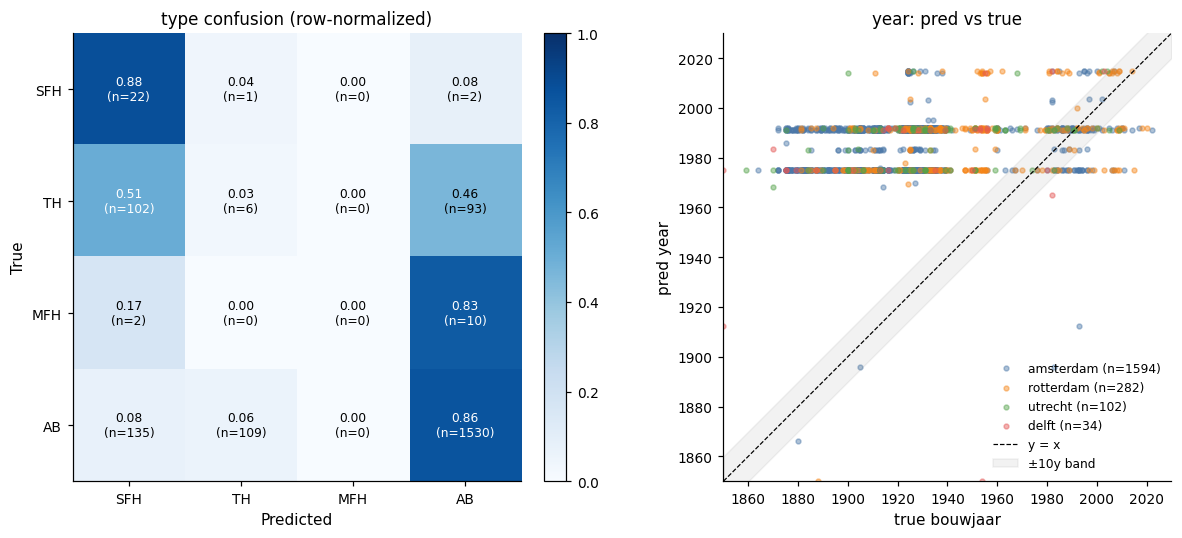

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm = np.asarray(ho_metrics['type_confusion_matrix']['matrix'])
labels = ho_metrics['type_confusion_matrix']['labels']
confusion_heatmap(cm, labels, axes[0], title='type confusion (row-normalized)')

ax = axes[1]
# Aggregated per-building predictions vs GT
scored = per_pand.dropna(subset=['pred_year', 'true_bouwjaar'])
for city in CITY_LABELS:
    sub = scored[scored['city'] == city]
    ax.scatter(sub['true_bouwjaar'], sub['pred_year'],
               s=10, alpha=0.45, color=CITY_PALETTE[city], label=f'{city} (n={len(sub)})')
lo, hi = AXIS_LIMITS['year_scatter']
ax.plot([lo, hi], [lo, hi], color='black', lw=0.8, linestyle='--', label='y = x')
ax.fill_between([lo, hi], [lo - 10, hi - 10], [lo + 10, hi + 10],
                color='gray', alpha=0.10, label='±10y band')
ax.set_xlim(*AXIS_LIMITS['year_scatter']); ax.set_ylim(*AXIS_LIMITS['year_scatter'])
ax.set_xlabel('true bouwjaar'); ax.set_ylabel('pred year')
ax.set_title('year: pred vs true')
ax.legend(frameon=False, fontsize=8, loc='lower right')
ax.set_aspect('equal', adjustable='box')

fig.tight_layout()
save_fig(fig, 'F1_vlm_holdout_type_year', 'vlm')
plt.show()

[fig] reports\figures\stage1\vlm\F2_vlm_per_class_per_city.png  +  F2_vlm_per_class_per_city.pdf


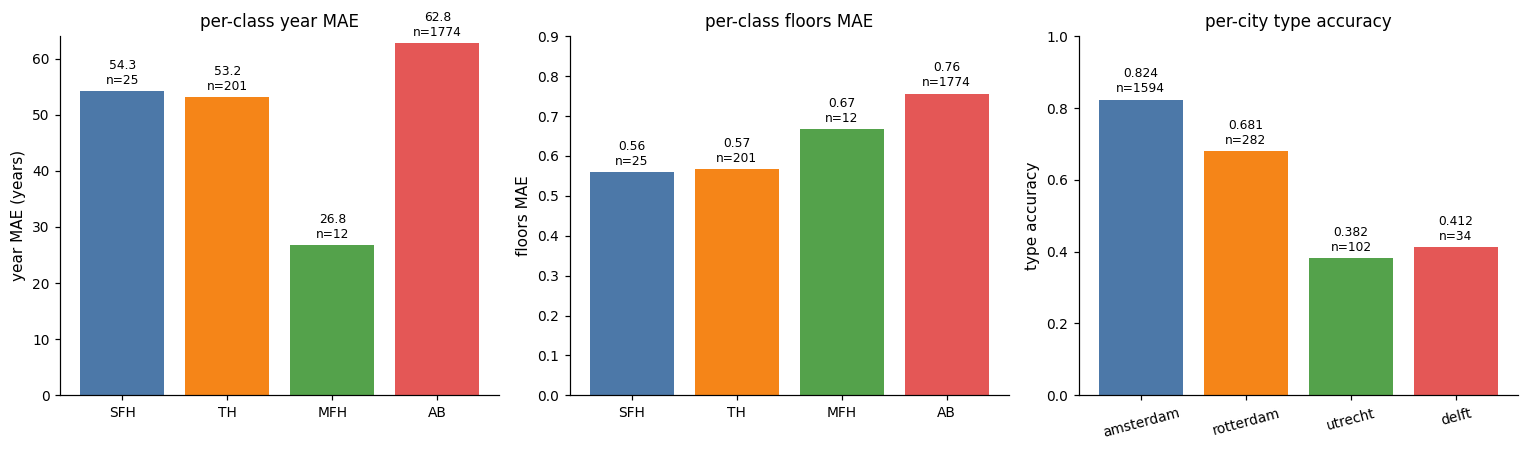

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))

pc = ho_metrics['per_class_year_floors']
y_vals = [pc[t]['year_mae'] for t in TYPE_LABELS]
f_vals = [pc[t]['floors_mae'] for t in TYPE_LABELS]
n_per_class = [pc[t]['n'] for t in TYPE_LABELS]
axes[0].bar(TYPE_LABELS, y_vals, color=[TYPE_PALETTE[t] for t in TYPE_LABELS])
axes[0].set_ylim(*AXIS_LIMITS['year_mae_bar'])
axes[0].set_ylabel('year MAE (years)')
axes[0].set_title('per-class year MAE')
for i, (v, n) in enumerate(zip(y_vals, n_per_class)):
    axes[0].text(i, v + AXIS_LIMITS['year_mae_bar'][1]*0.02, f'{v:.1f}\nn={n}', ha='center', fontsize=8)

axes[1].bar(TYPE_LABELS, f_vals, color=[TYPE_PALETTE[t] for t in TYPE_LABELS])
axes[1].set_ylim(*AXIS_LIMITS['floors_mae_bar'])
axes[1].set_ylabel('floors MAE')
axes[1].set_title('per-class floors MAE')
for i, (v, n) in enumerate(zip(f_vals, n_per_class)):
    axes[1].text(i, v + AXIS_LIMITS['floors_mae_bar'][1]*0.02, f'{v:.2f}\nn={n}', ha='center', fontsize=8)

per_city = ho_metrics['per_city']
city_acc = [per_city[c]['type_acc'] for c in CITY_LABELS]
city_n   = [per_city[c]['n'] for c in CITY_LABELS]
axes[2].bar(CITY_LABELS, city_acc, color=[CITY_PALETTE[c] for c in CITY_LABELS])
axes[2].set_ylim(*AXIS_LIMITS['type_acc_bar'])
axes[2].set_ylabel('type accuracy')
axes[2].set_title('per-city type accuracy')
for i, (v, n) in enumerate(zip(city_acc, city_n)):
    axes[2].text(i, v + 0.02, f'{v:.3f}\nn={n}', ha='center', fontsize=8)
axes[2].tick_params(axis='x', rotation=15)

fig.tight_layout()
save_fig(fig, 'F2_vlm_per_class_per_city', 'vlm')
plt.show()